# Feature Selection: Test

## Install libraries

In [1]:
# !pip install -r ../../requirements.txt

## Import libraries

In [2]:
import os
import sys
import pandas as pd

# go one level up from where the notebook is running
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from logger.logger import Logger
from feature_selector.feature_selector import (
    FeatureSelector,
    summarize_feature_importances,
    plot_final_feature_importances,
)
from utils.constants import *
from utils.enums import *
from dtos.tabular_database_driver_dtos.tabular_database_driver_dtos import *

## Helper functions

In [3]:
def auto_convert(df: pd.DataFrame) -> pd.DataFrame:
    for col in df.columns:
        # Dates
        if "date" in col.lower():
            df[col] = pd.to_datetime(df[col], errors="coerce")

        # Codes
        elif "code" in col.lower():
            df[col] = df[col].astype("string")

        # Market IDs
        elif "market_id" in col.lower():
            df[col] = pd.to_numeric(df[col], errors="coerce").astype("Int64")

        # OHLC
        elif col.lower() in ["open", "high", "low", "close"]:
            df[col] = pd.to_numeric(df[col], errors="coerce").astype(float)

        # Volume
        elif "volume" in col.lower():
            df[col] = pd.to_numeric(df[col], errors="coerce").astype("Int64")

    return df

## Initialize the Logger

In [4]:
my_logger = Logger(file_name=FEATURE_SELECTION_LOG_FILE_TEST)

## List all FeatureSelectorType

In [5]:
print([member.name for member in FeatureSelectorType])

['XGB_REGRESSOR', 'LASSO', 'ELASTIC_NET', 'XGB_SHAP']


## Initialize the Feature Selector

In [6]:
xgb_feature_selector = FeatureSelector(
    logger=my_logger, feature_selector_type=FeatureSelectorType.XGB_REGRESSOR
)

## Parameters

In [7]:
normalized_importances_dict = {}

In [8]:
# stock_code = "FPT"
output_column_name = "PJME_MW"

## Load data

In [9]:
df = pd.read_csv("../../src/PJME_hourly_date_features.csv")
df

,PJME_MW,hour,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear
0,26498.0,1,1,4,12,2002,365,31,1
1,25147.0,2,1,4,12,2002,365,31,1
2,24574.0,3,1,4,12,2002,365,31,1
3,24393.0,4,1,4,12,2002,365,31,1
4,24860.0,5,1,4,12,2002,365,31,1
...,...,...,...,...,...,...,...,...,...
145361,44284.0,20,0,1,1,2018,1,1,1
145362,43751.0,21,0,1,1,2018,1,1,1
145363,42402.0,22,0,1,1,2018,1,1,1
145364,40164.0,23,0,1,1,2018,1,1,1


In [10]:
train = df.loc[df.index < 120_000]
test = df.loc[df.index >= 120_000]

In [11]:
train

,PJME_MW,hour,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear
0,26498.0,1,1,4,12,2002,365,31,1
1,25147.0,2,1,4,12,2002,365,31,1
2,24574.0,3,1,4,12,2002,365,31,1
3,24393.0,4,1,4,12,2002,365,31,1
4,24860.0,5,1,4,12,2002,365,31,1
...,...,...,...,...,...,...,...,...,...
119995,31256.0,20,3,2,4,2015,113,23,17
119996,32298.0,21,3,2,4,2015,113,23,17
119997,31103.0,22,3,2,4,2015,113,23,17
119998,28782.0,23,3,2,4,2015,113,23,17


In [12]:
test

,PJME_MW,hour,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear
120000,22333.0,1,2,2,4,2015,112,22,17
120001,21547.0,2,2,2,4,2015,112,22,17
120002,21175.0,3,2,2,4,2015,112,22,17
120003,21118.0,4,2,2,4,2015,112,22,17
120004,21746.0,5,2,2,4,2015,112,22,17
...,...,...,...,...,...,...,...,...,...
145361,44284.0,20,0,1,1,2018,1,1,1
145362,43751.0,21,0,1,1,2018,1,1,1
145363,42402.0,22,0,1,1,2018,1,1,1
145364,40164.0,23,0,1,1,2018,1,1,1


## Feature Selection Type: XGB Regressor

In [13]:
xgb_feature_selector = FeatureSelector(
    logger=my_logger, feature_selector_type=FeatureSelectorType.XGB_REGRESSOR
)
xgb_feature_selector.connect_to_database(
    database_name=os.getenv("BRONZE_POSTGRES_DATABASE")
)

<DatabaseExecutionStatus.SUCCESS: 'success'>

In [14]:
xgb_feature_selector.fit(dataframe=train, target_column=output_column_name)

In [15]:
normalized_importances_dict[FeatureSelectorType.XGB_REGRESSOR.value["name"]] = (
    xgb_feature_selector.get_feature_importances()
)
xgb_feature_selector.get_feature_importances()

,feature,importance
0,hour,1.000000
1,month,0.587478
2,dayofyear,0.483756
3,dayofweek,0.467992
4,quarter,0.099598
5,weekofyear,0.078605
6,year,0.039976
7,dayofmonth,0.000000


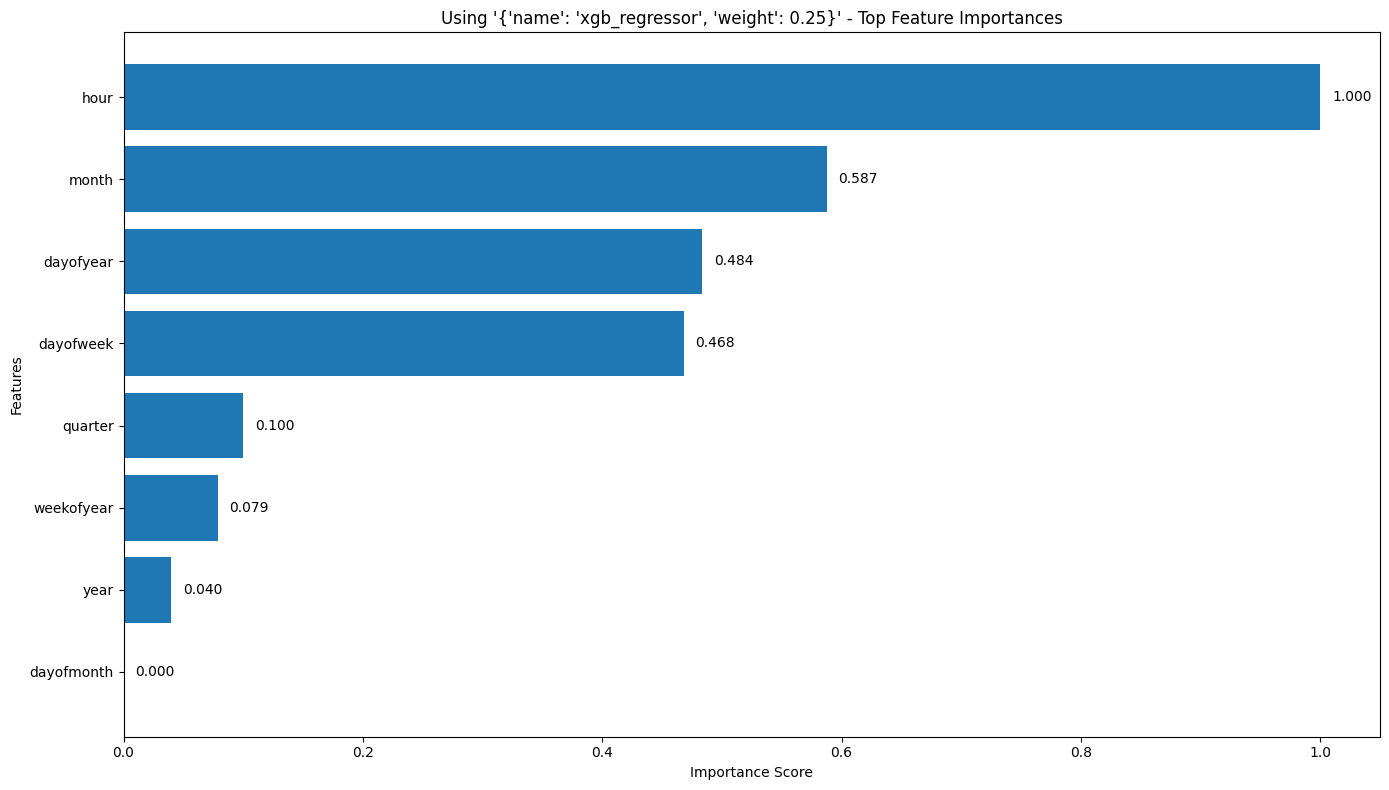

In [16]:
xgb_feature_selector.plot_feature_importances()

## Feature Selection Type: LASSO

In [17]:
lasso_feature_selector = FeatureSelector(
    logger=my_logger, feature_selector_type=FeatureSelectorType.LASSO
)
lasso_feature_selector.connect_to_database(
    database_name=os.getenv("BRONZE_POSTGRES_DATABASE")
)

<DatabaseExecutionStatus.SUCCESS: 'success'>

In [18]:
lasso_feature_selector.fit(dataframe=train, target_column=output_column_name)

In [19]:
normalized_importances_dict[FeatureSelectorType.LASSO.value["name"]] = (
    lasso_feature_selector.get_feature_importances()
)
lasso_feature_selector.get_feature_importances()

,feature,importance
0,hour,1.000000
1,dayofweek,0.328903
2,quarter,0.021220
3,month,0.000000
4,year,0.000000
5,dayofyear,0.000000
6,dayofmonth,0.000000
7,weekofyear,0.000000


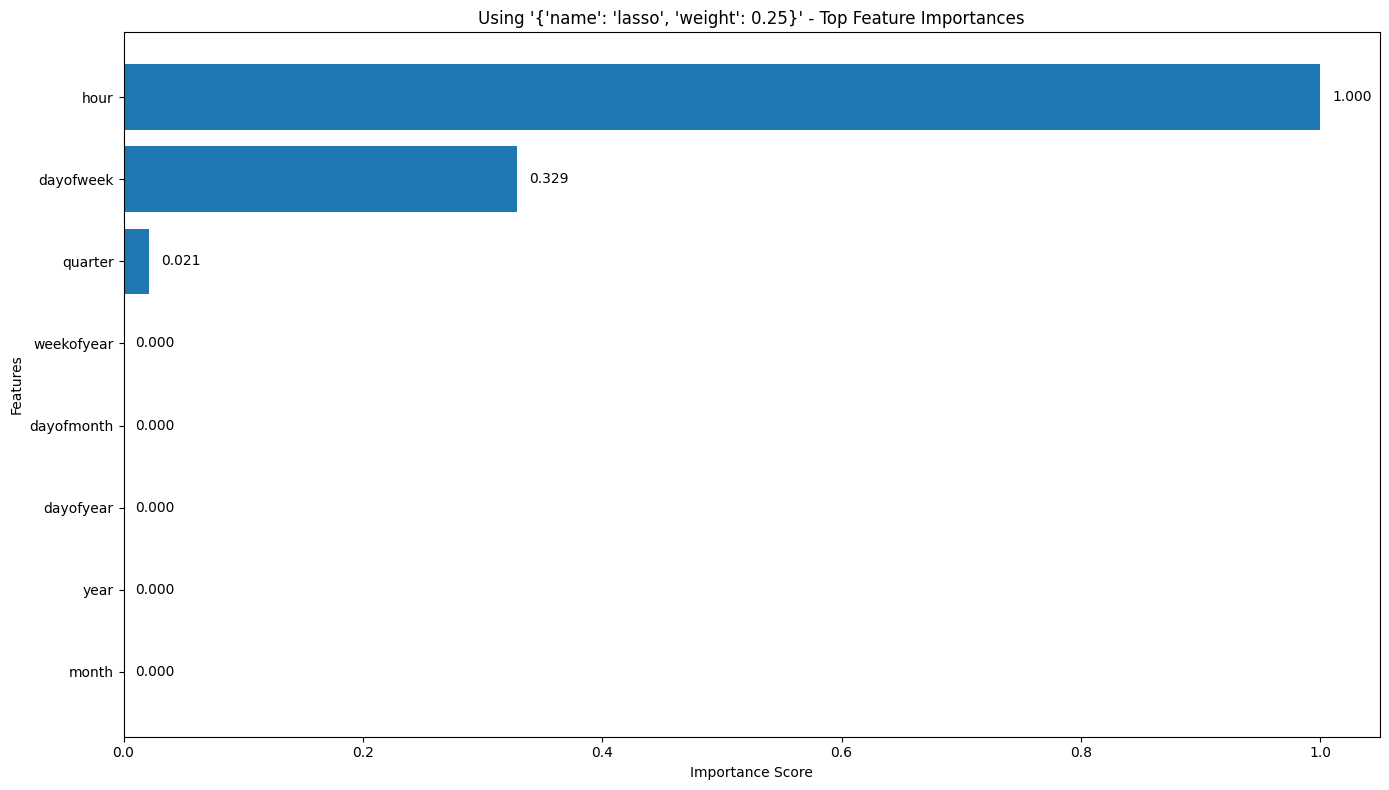

In [20]:
lasso_feature_selector.plot_feature_importances()

## Feature Selection Type: ELASTIC_NET

In [21]:
elastic_net_feature_selector = FeatureSelector(
    logger=my_logger, feature_selector_type=FeatureSelectorType.ELASTIC_NET
)
elastic_net_feature_selector.connect_to_database(
    database_name=os.getenv("BRONZE_POSTGRES_DATABASE")
)

<DatabaseExecutionStatus.SUCCESS: 'success'>

In [22]:
elastic_net_feature_selector.fit(dataframe=train, target_column=output_column_name)

In [23]:
normalized_importances_dict[FeatureSelectorType.ELASTIC_NET.value["name"]] = (
    elastic_net_feature_selector.get_feature_importances()
)
elastic_net_feature_selector.get_feature_importances()

,feature,importance
0,hour,1.000000
1,dayofweek,0.384611
2,year,0.066717
3,quarter,0.061369
4,month,0.057079
5,dayofyear,0.055860
6,weekofyear,0.054792
7,dayofmonth,0.000000


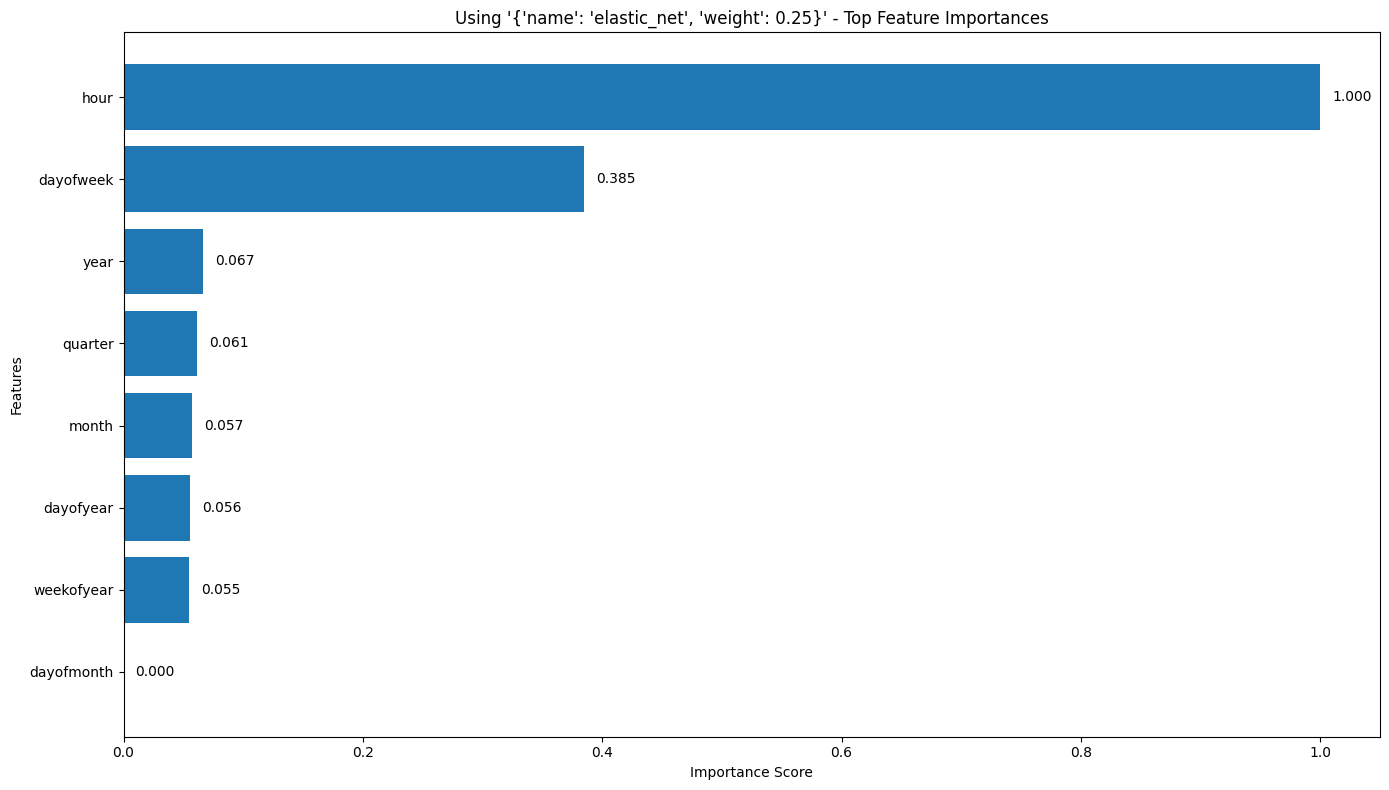

In [24]:
elastic_net_feature_selector.plot_feature_importances()

## Feature Selection Type: XGB_SHAP

In [25]:
xgb_shap_feature_selector = FeatureSelector(
    logger=my_logger, feature_selector_type=FeatureSelectorType.XGB_SHAP
)
xgb_shap_feature_selector.connect_to_database(
    database_name=os.getenv("BRONZE_POSTGRES_DATABASE")
)

<DatabaseExecutionStatus.SUCCESS: 'success'>

In [26]:
xgb_shap_feature_selector.fit(dataframe=train, target_column=output_column_name)

In [27]:
normalized_importances_dict[FeatureSelectorType.XGB_SHAP.value["name"]] = (
    xgb_shap_feature_selector.get_feature_importances()
)
xgb_shap_feature_selector.get_feature_importances()

,feature,importance
0,hour,1.000000
1,dayofyear,0.636602
2,dayofweek,0.375776
3,year,0.133282
4,weekofyear,0.117947
5,month,0.061404
6,dayofmonth,0.005940
7,quarter,0.000000


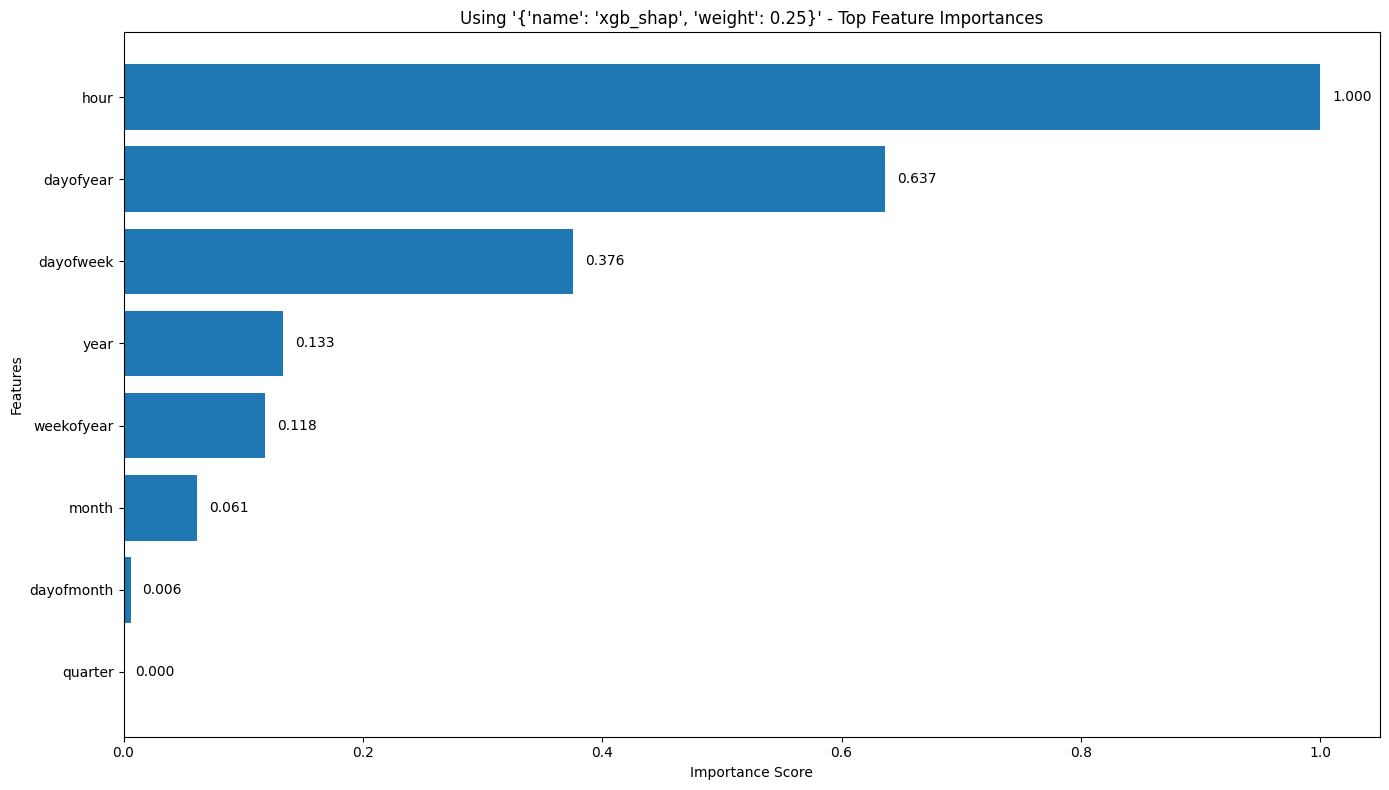

In [28]:
xgb_shap_feature_selector.plot_feature_importances()

## Normalize Feature Selection Types

In [29]:
normalized_importances_dict

{'xgb_regressor':       feature  importance
 0        hour    1.000000
 1       month    0.587478
 2   dayofyear    0.483756
 3   dayofweek    0.467992
 4     quarter    0.099598
 5  weekofyear    0.078605
 6        year    0.039976
 7  dayofmonth    0.000000,
 'lasso':       feature  importance
 0        hour    1.000000
 1   dayofweek    0.328903
 2     quarter    0.021220
 3       month    0.000000
 4        year    0.000000
 5   dayofyear    0.000000
 6  dayofmonth    0.000000
 7  weekofyear    0.000000,
 'elastic_net':       feature  importance
 0        hour    1.000000
 1   dayofweek    0.384611
 2        year    0.066717
 3     quarter    0.061369
 4       month    0.057079
 5   dayofyear    0.055860
 6  weekofyear    0.054792
 7  dayofmonth    0.000000,
 'xgb_shap':       feature  importance
 0        hour    1.000000
 1   dayofyear    0.636602
 2   dayofweek    0.375776
 3        year    0.133282
 4  weekofyear    0.117947
 5       month    0.061404
 6  dayofmonth    0.005940

In [30]:
weights = {
    FeatureSelectorType.XGB_REGRESSOR.value[
        "name"
    ]: FeatureSelectorType.XGB_REGRESSOR.value["weight"],
    FeatureSelectorType.LASSO.value["name"]: FeatureSelectorType.LASSO.value["weight"],
    FeatureSelectorType.ELASTIC_NET.value[
        "name"
    ]: FeatureSelectorType.ELASTIC_NET.value["weight"],
    FeatureSelectorType.XGB_SHAP.value["name"]: FeatureSelectorType.XGB_SHAP.value[
        "weight"
    ],
}
weights

{'xgb_regressor': 0.25, 'lasso': 0.25, 'elastic_net': 0.25, 'xgb_shap': 0.25}

In [31]:
final_df = summarize_feature_importances(
    normalized_importances_dict=normalized_importances_dict, weights=weights
)
final_df

,feature,xgb_regressor,lasso,elastic_net,xgb_shap,xgb_regressor_weighted,lasso_weighted,elastic_net_weighted,xgb_shap_weighted,final_importance
0,hour,1.000000,1.000000,1.000000,1.000000,0.250000,0.250000,0.250000,0.250000,1.000000
1,dayofweek,0.467992,0.328903,0.384611,0.375776,0.116998,0.082226,0.096153,0.093944,0.389321
2,dayofyear,0.483756,0.000000,0.055860,0.636602,0.120939,0.000000,0.013965,0.159150,0.294054
3,month,0.587478,0.000000,0.057079,0.061404,0.146870,0.000000,0.014270,0.015351,0.176490
4,weekofyear,0.078605,0.000000,0.054792,0.117947,0.019651,0.000000,0.013698,0.029487,0.062836
5,year,0.039976,0.000000,0.066717,0.133282,0.009994,0.000000,0.016679,0.033321,0.059994
6,quarter,0.099598,0.021220,0.061369,0.000000,0.024899,0.005305,0.015342,0.000000,0.045547
7,dayofmonth,0.000000,0.000000,0.000000,0.005940,0.000000,0.000000,0.000000,0.001485,0.001485


✅ Plot saved to: d:\GIT\master-thesis\charts\feature_selection\sample_final_feature_importances.png


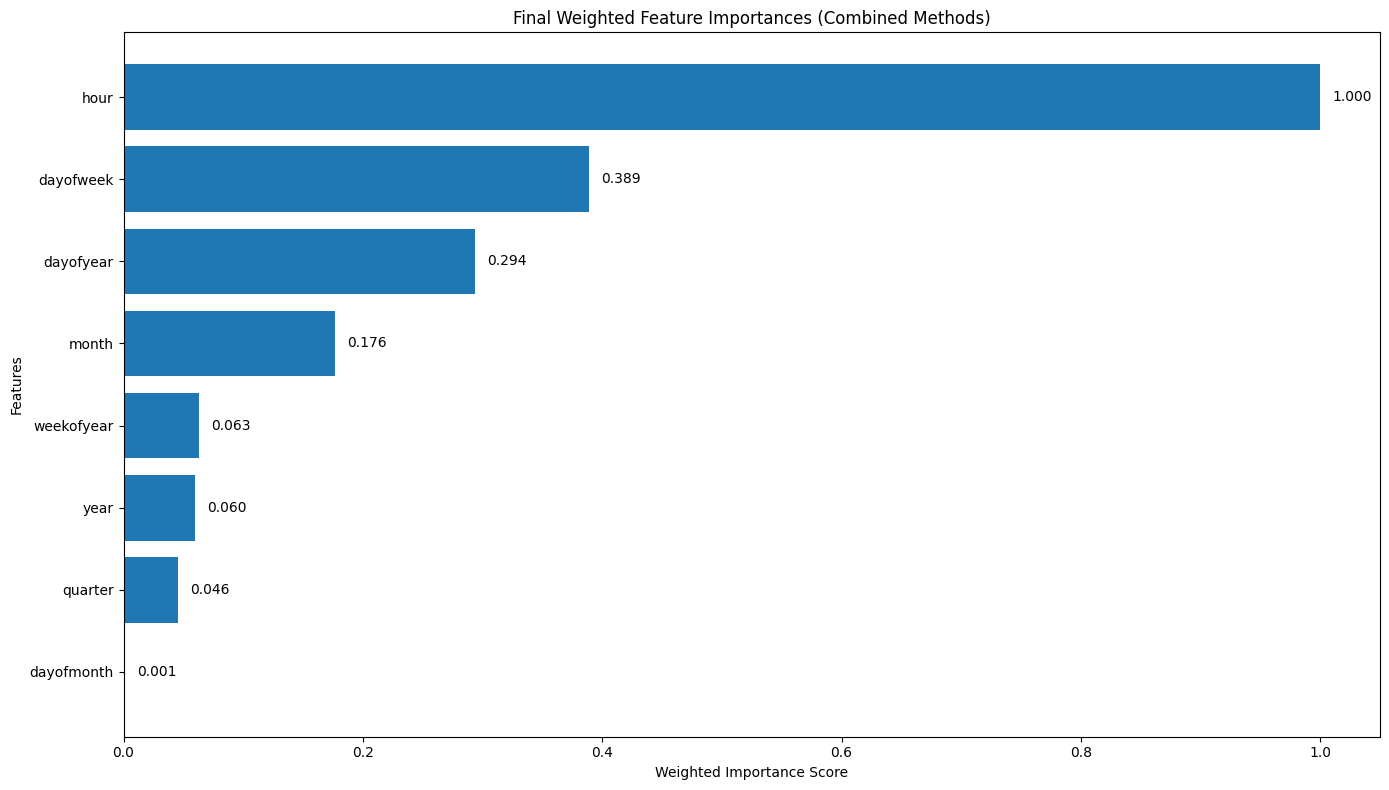

In [32]:
plot_final_feature_importances(
    combined_df=final_df,
    filename="sample_final_feature_importances.png",
)